In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading csv into SQL

df = pd.read_csv("HR-Employee-Attrition.csv")
print(df.shape)
print(df.columns.tolist())

conn = sqlite3.connect(':memory:')
df.to_sql('employees', conn, index=False, if_exists='replace')

(1470, 35)
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


1470

In [3]:
# Attrition rate by department

query1 = """
SELECT Department,
       COUNT(*) AS total_employees,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS left_count,
       ROUND(100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS attrition_rate
FROM employees
GROUP BY Department
ORDER BY attrition_rate DESC;
"""
dept_attrition = pd.read_sql_query(query1, conn)
print(dept_attrition)

               Department  total_employees  left_count  attrition_rate
0                   Sales              446          92           20.63
1         Human Resources               63          12           19.05
2  Research & Development              961         133           13.84


In [4]:
# Attrition rate by job role

query2 = """
SELECT JobRole,
       COUNT(*) AS total_employees,
       ROUND(100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS attrition_rate
FROM employees
GROUP BY JobRole
ORDER BY attrition_rate DESC;
"""
role_attrition = pd.read_sql_query(query2, conn)
print(role_attrition)

                     JobRole  total_employees  attrition_rate
0       Sales Representative               83           39.76
1      Laboratory Technician              259           23.94
2            Human Resources               52           23.08
3            Sales Executive              326           17.48
4         Research Scientist              292           16.10
5     Manufacturing Director              145            6.90
6  Healthcare Representative              131            6.87
7                    Manager              102            4.90
8          Research Director               80            2.50


In [5]:
# Does overtime correlate with attrition

query3 = """
SELECT OverTime,
       COUNT(*) AS total_employees,
       ROUND(100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS attrition_rate
FROM employees
GROUP BY OverTime;
"""
overtime_attrition = pd.read_sql_query(query3, conn)
print(overtime_attrition)

  OverTime  total_employees  attrition_rate
0       No             1054           10.44
1      Yes              416           30.53


In [6]:
# Attrition by age group

query4 = """
SELECT
  CASE
    WHEN Age < 25 THEN 'Under 25'
    WHEN Age BETWEEN 25 AND 34 THEN '25-34'
    WHEN Age BETWEEN 35 AND 44 THEN '35-44'
    ELSE '45+'
  END AS age_group,
  COUNT(*) AS total_employees,
  ROUND(100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS attrition_rate
FROM employees
GROUP BY age_group
ORDER BY attrition_rate DESC;
"""
age_attrition = pd.read_sql_query(query4, conn)
print(age_attrition)

  age_group  total_employees  attrition_rate
0  Under 25               97           39.18
1     25-34              554           20.22
2       45+              314           11.46
3     35-44              505           10.10


In [7]:
# Departments above company wide average

query5 = """
SELECT Department, attrition_rate FROM (
    SELECT Department,
           ROUND(100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS attrition_rate
    FROM employees
    GROUP BY Department
) AS dept_rates
WHERE attrition_rate > (
    SELECT ROUND(100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2)
    FROM employees
);
"""
above_avg = pd.read_sql_query(query5, conn)
print(above_avg)

        Department  attrition_rate
0  Human Resources           19.05
1            Sales           20.63


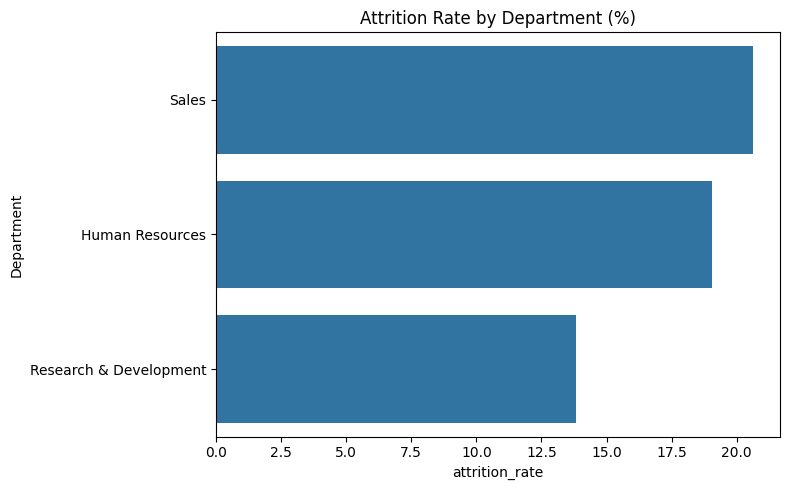

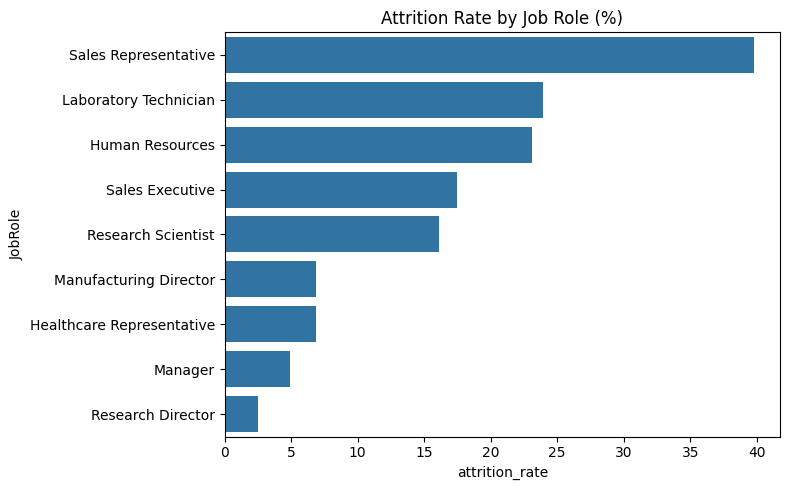

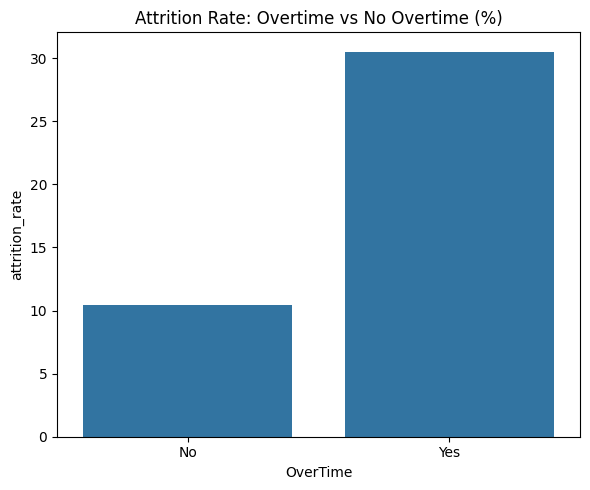

In [8]:
# Visualization

plt.figure(figsize=(8, 5))
sns.barplot(data=dept_attrition, x='attrition_rate', y='Department')
plt.title("Attrition Rate by Department (%)")
plt.tight_layout()
plt.savefig("attrition_by_department.png")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=role_attrition, x='attrition_rate', y='JobRole')
plt.title("Attrition Rate by Job Role (%)")
plt.tight_layout()
plt.savefig("attrition_by_jobrole.png")
plt.show()

plt.figure(figsize=(6, 5))
sns.barplot(data=overtime_attrition, x='OverTime', y='attrition_rate')
plt.title("Attrition Rate: Overtime vs No Overtime (%)")
plt.tight_layout()
plt.savefig("attrition_by_overtime.png")
plt.show()

## Key Insights

- Sales has the highest attrition among departments at 20.63%, compared to 19.05% in HR and only 13.84% in Research & Development.
- Sales Representatives leave at the highest rate of any job role (39.76%), far above Laboratory Technicians (23.94%) and HR staff (23.08%). Managers and Research Directors rarely leave (under 5%).
- Employees who work overtime have a 30.53% attrition rate, nearly three times higher than employees who don't work overtime (10.44%).
- Younger employees leave far more often — under-25s have a 39.18% attrition rate, dropping steadily to just 10.10% for 35-44 year-olds.
- Both Sales (20.63%) and HR (19.05%) have attrition rates above the company-wide average, flagging them as priority areas for retention.

**Summary:** Sales Representatives, employees under 25, and people working overtime are the groups most likely to leave — and overtime alone almost triples someone's chance of quitting.